# TP 2 — Régression Linéaire & Régression Logistique

Ce notebook couvre deux parties :
1. **Régression Linéaire** — Prédire la consommation de carburant (MPG) à partir du dataset Auto MPG
2. **Régression Logistique** — Prédire l'admission d'un étudiant à partir du dataset Binary (UCLA)

---
## Partie 1 — Régression Linéaire
### 1.1 Import des bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
print('Bibliothèques importées avec succès ')

Bibliothèques importées avec succès 


### 1.2 Chargement des données

On utilise le jeu de données **Auto MPG** pour prédire la consommation de carburant (MPG) en fonction de caractéristiques techniques des voitures.

In [3]:
# Chargement du CSV 
dataset_path = r"C:\Users\ihssa\OneDrive\Desktop\intro sci donnees\auto-mpg.csv"

raw_dataset = pd.read_csv(dataset_path)

# Renommage des colonnes 
raw_dataset.columns = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year']

raw_dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [5]:
# Copie du dataset et dimensions
dataSet = raw_dataset.copy()
print('Colonnes :', dataSet.columns.tolist())
print('Dimensions :', dataSet.shape)

Colonnes : ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year']
Dimensions : (398, 7)


### 1.3 Prétraitement des données

In [6]:
# Vérification des valeurs manquantes
dataSet.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      2
Weight          0
Acceleration    0
Model Year      0
dtype: int64

In [7]:
# Suppression des lignes avec valeurs manquantes
dataSet = dataSet.dropna()
print('Après suppression des NaN :')
dataSet.isnull().sum()

Après suppression des NaN :


MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
dtype: int64

### 1.4 Exploration visuelle

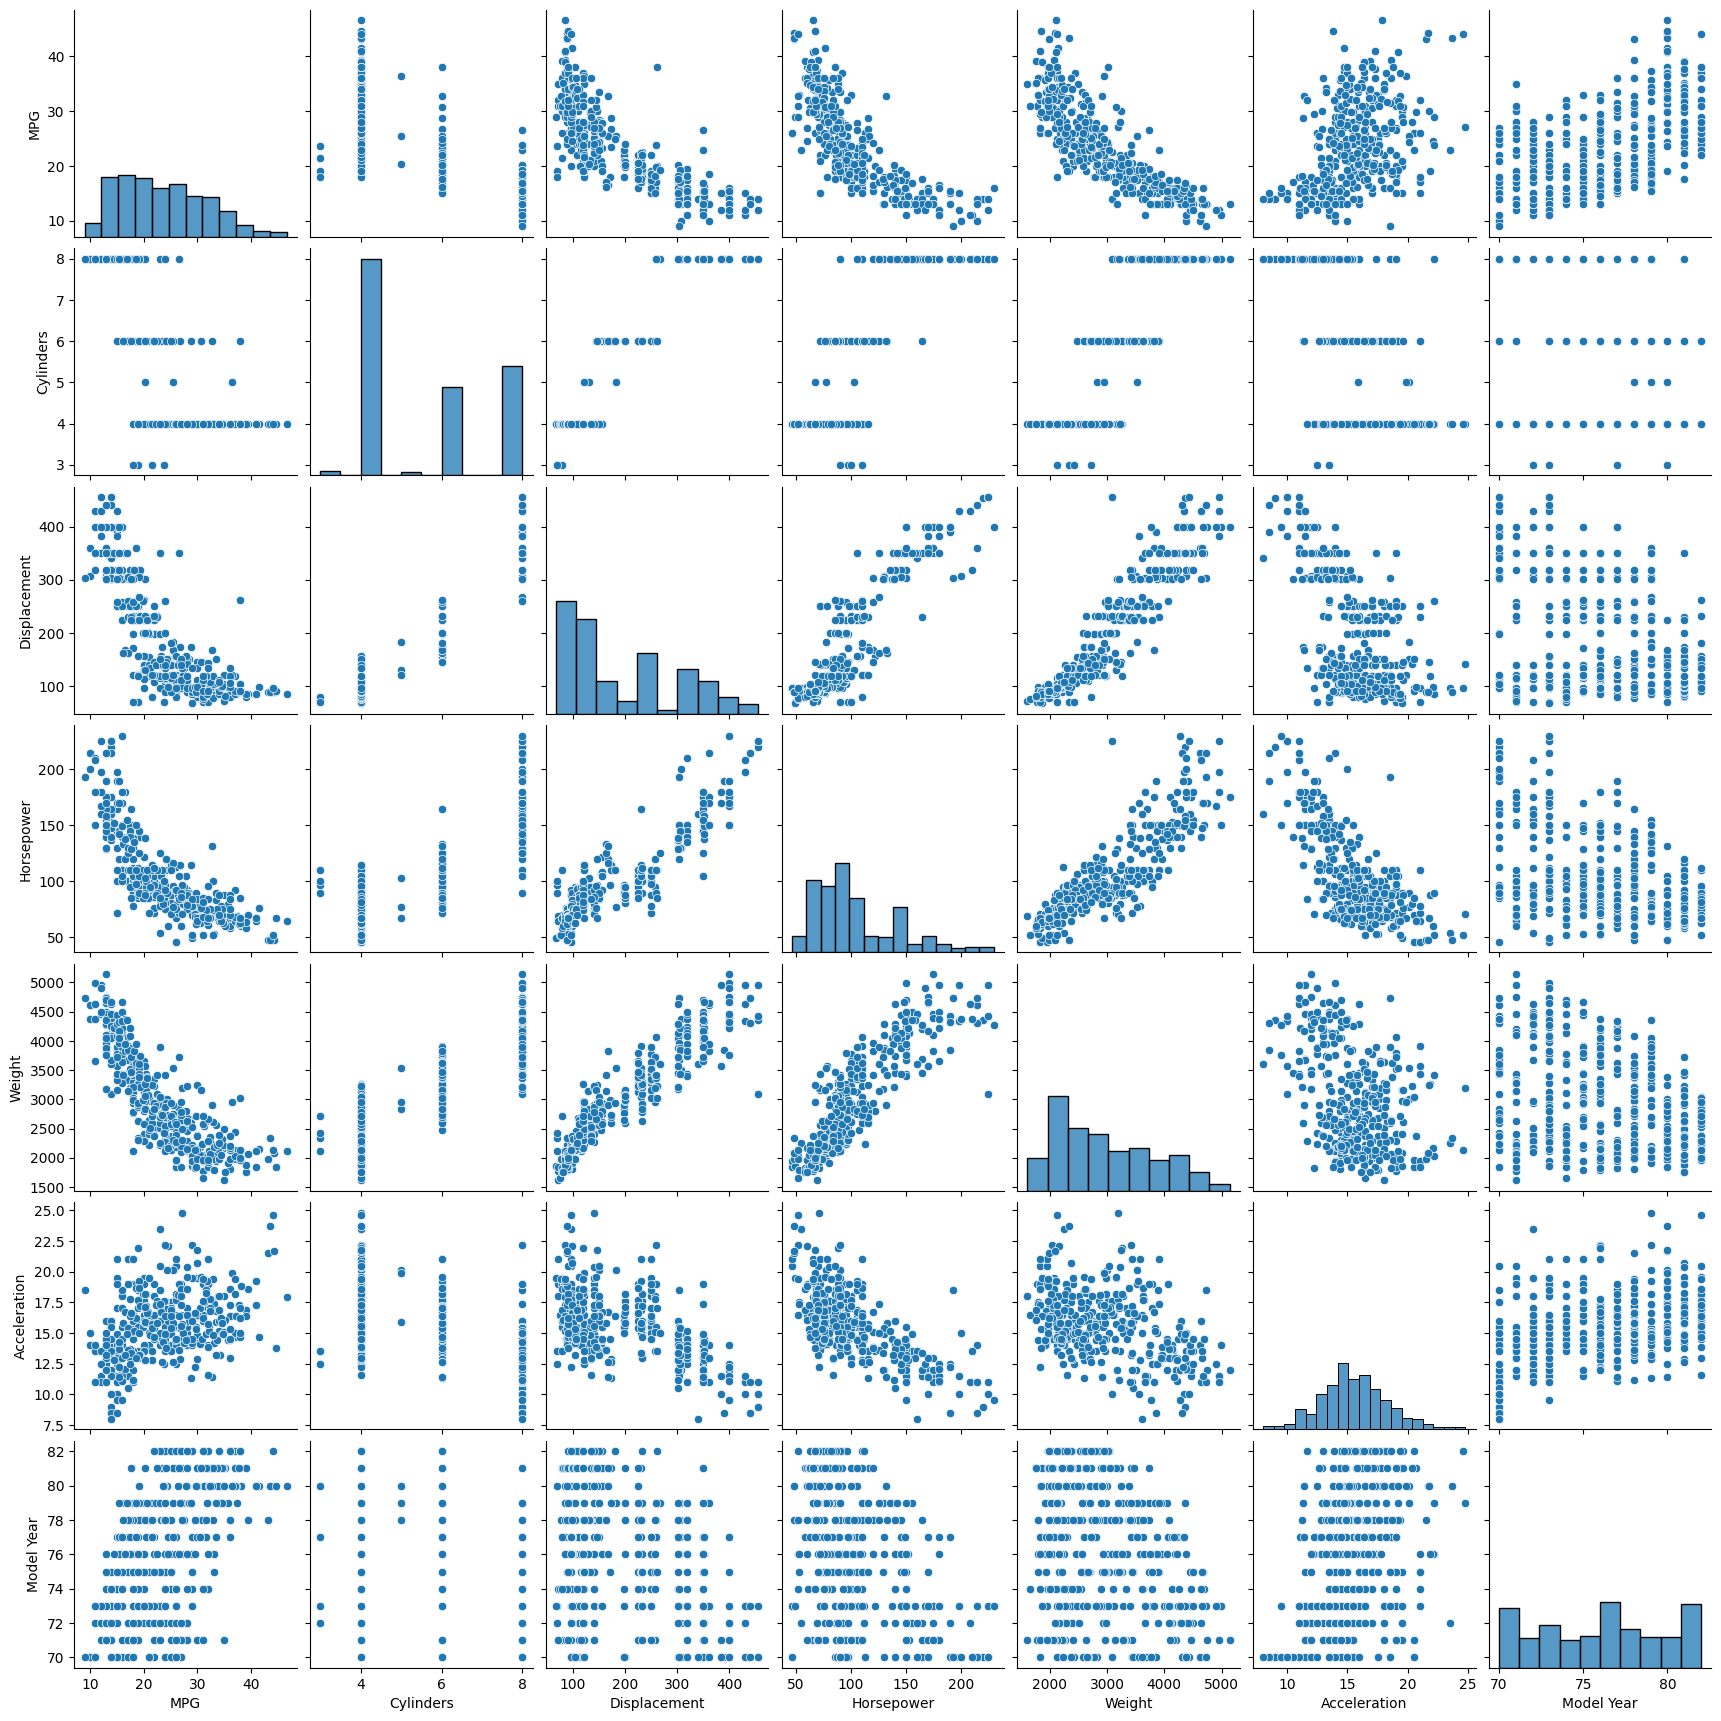

In [8]:
# Pairplot de toutes les variables
sns.pairplot(dataSet)
plt.show()

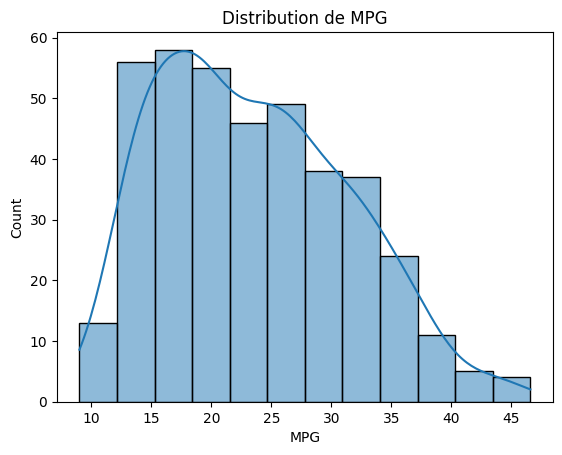

In [9]:
# Distribution de la variable cible MPG
sns.histplot(dataSet['MPG'], kde=True)  # sns.distplot est déprécié → on utilise histplot
plt.title('Distribution de MPG')
plt.show()

                   MPG  Cylinders  Displacement  Horsepower    Weight  \
MPG           1.000000  -0.775680     -0.804711   -0.777575 -0.832725   
Cylinders    -0.775680   1.000000      0.950706    0.843751  0.896058   
Displacement -0.804711   0.950706      1.000000    0.897787  0.932729   
Horsepower   -0.777575   0.843751      0.897787    1.000000  0.864350   
Weight       -0.832725   0.896058      0.932729    0.864350  1.000000   
Acceleration  0.421159  -0.504844     -0.542713   -0.687241 -0.415462   
Model Year    0.581144  -0.352554     -0.374620   -0.420697 -0.311774   

              Acceleration  Model Year  
MPG               0.421159    0.581144  
Cylinders        -0.504844   -0.352554  
Displacement     -0.542713   -0.374620  
Horsepower       -0.687241   -0.420697  
Weight           -0.415462   -0.311774  
Acceleration      1.000000    0.294588  
Model Year        0.294588    1.000000  


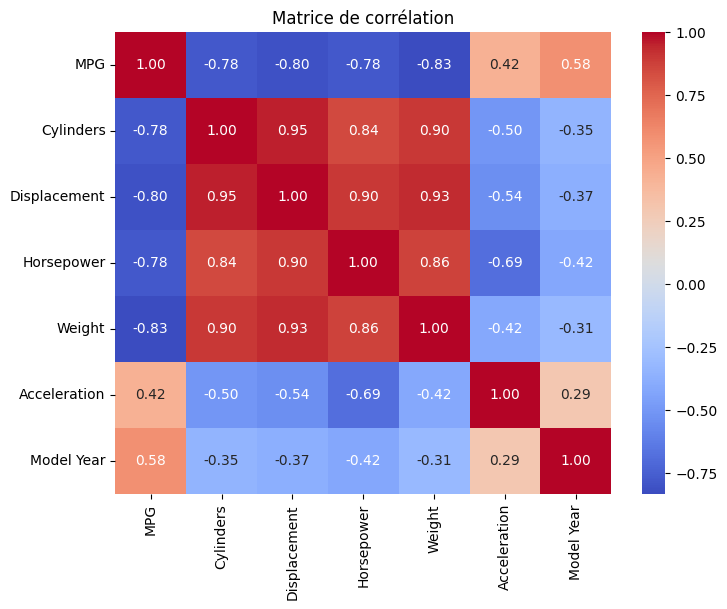

In [10]:
# Matrice de corrélation
cor = dataSet.corr(numeric_only=True)
print(cor)

plt.figure(figsize=(8, 6))
sns.heatmap(cor, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

**Interprétation :** Le coefficient de corrélation varie entre -1 et 1.  
- Proche de **1** → forte corrélation positive  
- Proche de **-1** → forte corrélation négative

Les variables **Displacement**, **Horsepower** et **Weight** sont fortement corrélées avec MPG.

### 1.5 Fractionnement train / test (70% / 30%)

In [11]:
X = dataSet.drop('MPG', axis=1)
Y = dataSet['MPG']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=20)

print('Taille entraînement :', X_train.shape)
print('Taille test         :', X_test.shape)

Taille entraînement : (277, 6)
Taille test         : (119, 6)


### 1.6 Génération du modèle de régression linéaire

In [12]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)
print('Modèle entraîné ✓')

Modèle entraîné ✓


### 1.7 Évaluation du modèle

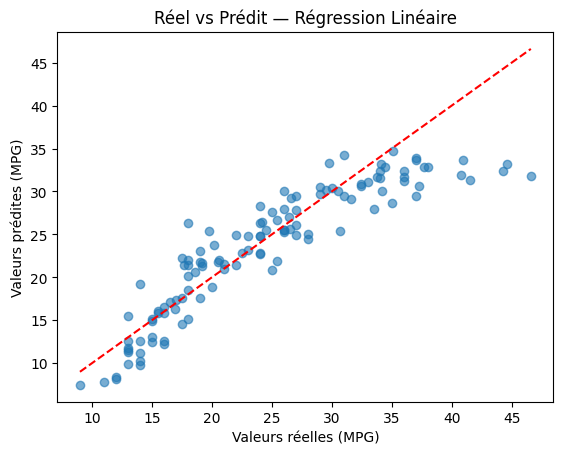

In [13]:
predictions = lin_model.predict(X_test)

# Scatter plot : valeurs réelles vs prédites
plt.scatter(Y_test, predictions, alpha=0.6)
plt.xlabel('Valeurs réelles (MPG)')
plt.ylabel('Valeurs prédites (MPG)')
plt.title('Réel vs Prédit — Régression Linéaire')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # ligne idéale
plt.show()

In [14]:
# Métriques d'évaluation
mse = mean_squared_error(Y_test, predictions)
accuracy = r2_score(Y_test, predictions)

print(f'MSE (Mean Squared Error) : {mse:.2f}')
print(f'R² Score (Précision)     : {accuracy:.2f}')

MSE (Mean Squared Error) : 14.21
R² Score (Précision)     : 0.81


---
## Partie 2 — Régression Logistique
### 2.1 Import des bibliothèques

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing, metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('Bibliothèques importées avec succès ✓')

Bibliothèques importées avec succès ✓


### 2.2 Chargement du jeu de données

Données de régression logistique fournies par l'UCLA (Institut de recherche et d'éducation numériques).

| Colonne | Description |
|---|---|
| `admit` | 0 = non admis, 1 = admis |
| `gre` | Score au Graduate Record Examination |
| `gpa` | Grade Point Average (moyenne académique) |
| `rank` / `prestige` | Niveau de prestige de l'établissement (1 = meilleur) |

In [16]:
dataset_chemin = r"C:\Users\ihssa\OneDrive\Desktop\intro sci donnees\binary.csv"
dataset=pd.read_csv(dataset_chemin)
dataset.columns = ['admit', 'gre', 'gpa', 'prestige']

print('Dimensions :', dataset.shape)
dataset.head()

Dimensions : (400, 4)


,admit,gre,gpa,prestige
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


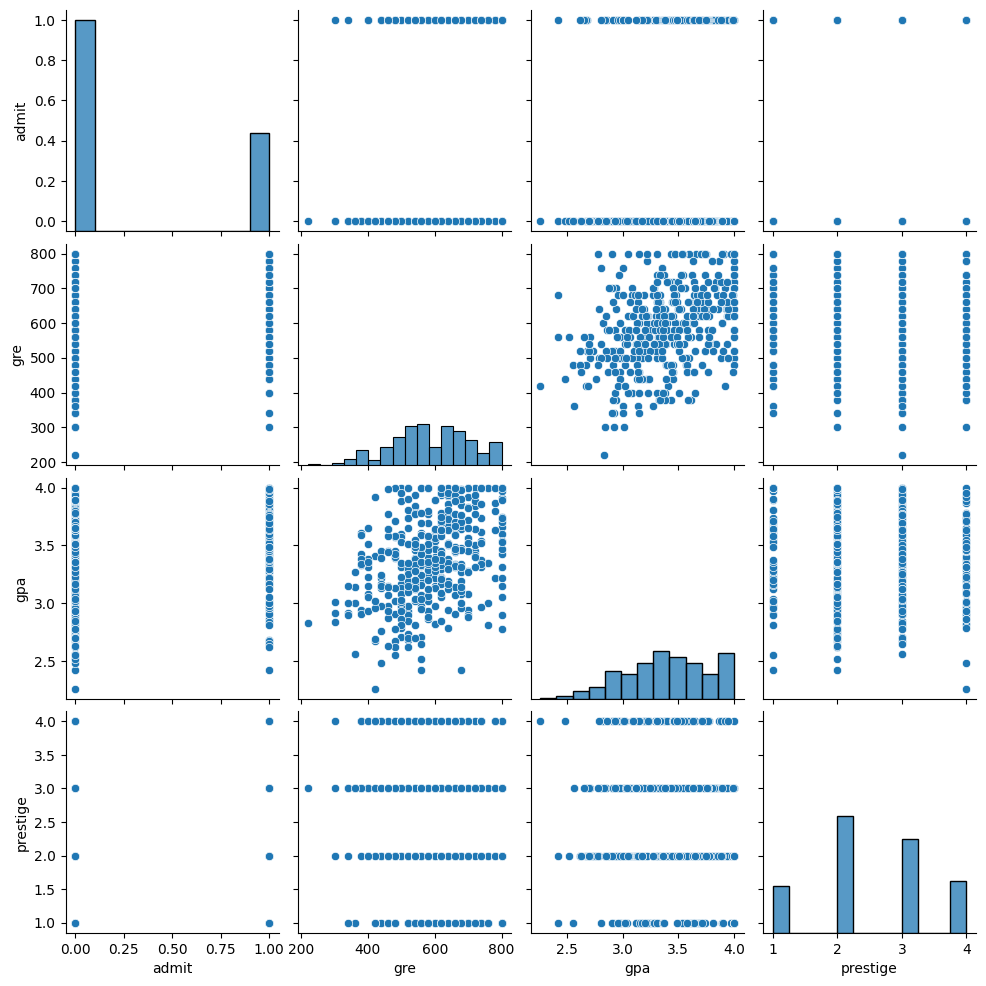

In [17]:
# Visualisation de toutes les variables
sns.pairplot(dataset)
plt.show()

### 2.3 Prétraitement des données

In [18]:
# Vérification des valeurs manquantes
dataset.isnull().sum()

admit       0
gre         0
gpa         0
prestige    0
dtype: int64

In [19]:
# Encodage one-hot de la variable catégorielle 'prestige'
dummy_ranks = pd.get_dummies(dataset['prestige'], prefix='prestige')
dummy_ranks.head()

,prestige_1,prestige_2,prestige_3,prestige_4
0,False,False,True,False
1,False,False,True,False
2,True,False,False,False
3,False,False,False,True
4,False,False,False,True


In [20]:
# Création du dataset final pour la régression
cols = ['admit', 'gre', 'gpa']
data = dataset[cols].join(dummy_ranks)

# Distribution de la variable cible
print('Distribution de admit :')
print(data['admit'].value_counts())

data.head()

Distribution de admit :
admit
0    273
1    127
Name: count, dtype: int64


,admit,gre,gpa,prestige_1,prestige_2,prestige_3,prestige_4
0,0,380,3.61,False,False,True,False
1,1,660,3.67,False,False,True,False
2,1,800,4.00,True,False,False,False
3,1,640,3.19,False,False,False,True
4,0,520,2.93,False,False,False,True


### 2.4 Fractionnement train / test (70% / 30%)

In [21]:
x = data.drop('admit', axis=1)
y = data['admit']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

print('Taille entraînement :', x_train.shape)
print('Taille test         :', x_test.shape)

Taille entraînement : (280, 6)
Taille test         : (120, 6)


### 2.5 Génération du modèle de régression logistique

In [22]:
logmodel = LogisticRegression(C=1e20, max_iter=1000)  # max_iter augmenté pour la convergence
logmodel.fit(x_train, y_train)
print('Modèle entraîné ✓')

Modèle entraîné ✓


### 2.6 Modèle obtenu — Coefficients

In [23]:
print('Intercept :', logmodel.intercept_)
print('Coefficients :', logmodel.coef_)

# Affichage lisible des coefficients
coef_df = pd.DataFrame({'Variable': x.columns, 'Coefficient': logmodel.coef_[0]})
print('\n', coef_df)

Intercept : [-3.80082214]
Coefficients : [[ 1.53161859e-03  8.96018196e-01 -2.70720561e-01 -5.68086686e-01
  -1.33793074e+00 -1.62408415e+00]]

      Variable  Coefficient
0         gre     0.001532
1         gpa     0.896018
2  prestige_1    -0.270721
3  prestige_2    -0.568087
4  prestige_3    -1.337931
5  prestige_4    -1.624084


La fonction de score (log-odds) est :

$$z = \beta_0 + \beta_1 \cdot gre + \beta_2 \cdot gpa + \beta_3 \cdot prestige\_1 + \beta_4 \cdot prestige\_2 + \beta_5 \cdot prestige\_3 + \beta_6 \cdot prestige\_4$$

La probabilité d'admission est ensuite : $P(admit=1) = \frac{1}{1 + e^{-z}}$

### 2.7 Évaluation du modèle

In [24]:
y_pred = logmodel.predict(x_test)
print('Prédictions :', y_pred)

Prédictions : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0
 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 1 0 0 0 1 0 0 0 1]


In [25]:
# Métriques
count_misclassified = (y_test != y_pred).sum()
accuracy = metrics.accuracy_score(y_test, y_pred)

print(f'Échantillons mal classés : {count_misclassified}')
print(f'Précision                : {accuracy:.2f}')

Échantillons mal classés : 31
Précision                : 0.74


In [26]:
# Rapport de classification détaillé
print(metrics.classification_report(y_test, y_pred, target_names=['Non admis', 'Admis']))

              precision    recall  f1-score   support

   Non admis       0.76      0.91      0.83        82
       Admis       0.67      0.37      0.47        38

    accuracy                           0.74       120
   macro avg       0.71      0.64      0.65       120
weighted avg       0.73      0.74      0.72       120



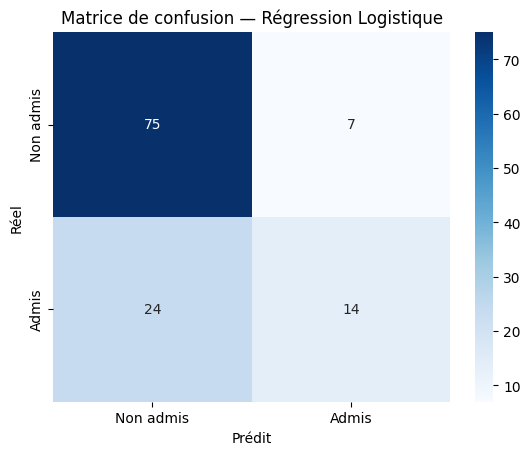

In [27]:
# Matrice de confusion
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non admis', 'Admis'],
            yticklabels=['Non admis', 'Admis'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion — Régression Logistique')
plt.show()